# Tarea 1 : Jose Foitzcik
Dataset escodigo: **creditcard.csv**  (En un inicio habia escogido la version 2023 pero era una version sintetica y al entrenar el modelo base ya no tenia fallos, solo 3 errores en la matriz de confusión, por lo que decidi optar por una versión mas antigua y real del modelo).

**Link del Dataset:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download

**El Resumen del proceso experimental en conjunto a los resultados de toda la actividad se encuentran resumidos al final del collab.** (Partiendo desde la sección: El problema a abordar)

# Importar librerias y Configuración

In [ ]:
# [setup]
import os, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# --- Nuevas imports para EDA ---
import pandas as pd
import seaborn as sns

# Configs del profesor
torch.set_float32_matmul_precision('high')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
os.makedirs('checkpoints', exist_ok=True)
print('Device:', DEVICE)

# Copiamos la función set_seed (Celda 2 del profesor)
def set_seed(seed=42):
    import random
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

Device: cuda


# Analisis de los datos (Desbalance a favor de isFraud = False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

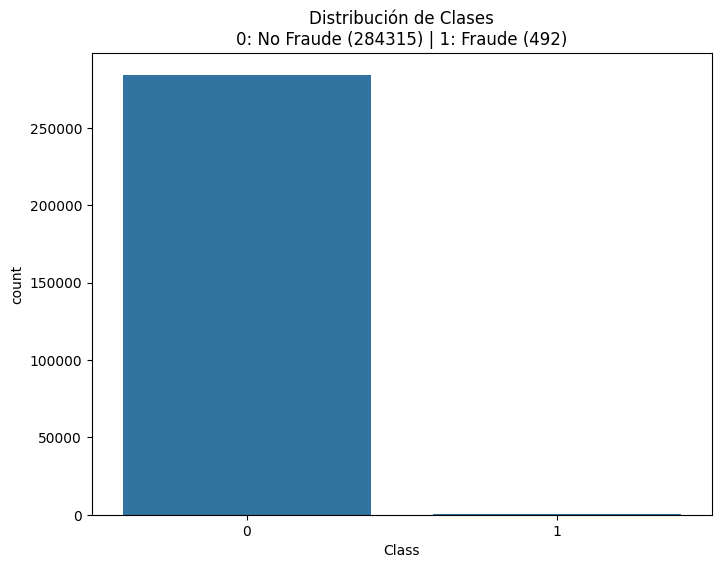

In [ ]:
# --- Cargar el Dataset (creditcard.csv) ---
try:
    df = pd.read_csv('creditcard.csv')
except FileNotFoundError:
    print("Error: 'creditcard.csv' no encontrado.")
    print("Por favor, descarga el dataset original de Kaggle y colócalo en la misma carpeta.")

if 'df' in locals():
    # Vistazo rápido y chequeo de nulos
    print(df.info())
    print(f"\nValores nulos totales: {df.isnull().sum().sum()}")

    # --- ❗️ ANÁLISIS DEL DESBALANCE ---
    print("\n--- Distribución de Clases ---")
    class_counts = df['Class'].value_counts()
    class_percents = df['Class'].value_counts(normalize=True) * 100
    print(class_counts)
    if 1 in class_percents:
        print(f"\nPorcentaje Fraude (1): {class_percents[1]:.3f}%")
        print(f"Porcentaje No Fraude (0): {class_percents[0]:.3f}%")
    else:
        print("\nError: No se encontró la clase '1' (Fraude) en el dataset.")

    # --- 📊 Visualización del Desbalance ---
    plt.figure(figsize=(8, 6))
    sns.countplot(x='Class', data=df)
    plt.title(f'Distribución de Clases\n0: No Fraude ({class_counts[0]}) | 1: Fraude ({class_counts[1]})')
    plt.show()

# Preparación de Datos y Escalado

In [ ]:
# [compat: tensor dataset helper] (Celda 4 del profesor)
def to_tensor_dataset(X, y, *, standardize=False, test_size=0.2, val_size=0.2, seed=42, y_is_float=False):
    if standardize:
        # Nota: El dataset de fraude tiene V1-V28 (ya escalados por PCA)
        # pero 'Time' y 'Amount' NO están escalados. StandardScaler los normalizará.
        scaler = StandardScaler().fit(X)
        X = scaler.transform(X)

    X = torch.tensor(X, dtype=torch.float32)
    if y_is_float:
        y = torch.tensor(y, dtype=torch.float32).view(-1)
    else:
        y = torch.tensor(y, dtype=torch.long).view(-1)

    # La estratificación (stratify=y) es VITAL aquí
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, stratify=y if not y_is_float else None, random_state=seed)
    X_tr, X_val, y_tr, y_val = train_test_split(X_tr, y_tr, test_size=val_size, stratify=y_tr if not y_is_float else None, random_state=seed)

    print("\n--- Conteo de Clases (después del split estratificado) ---")
    print(f"Train: {np.sum(y_tr.numpy() == 1)} fraudes")
    print(f"Val:   {np.sum(y_val.numpy() == 1)} fraudes")
    print(f"Test:  {np.sum(y_te.numpy() == 1)} fraudes")

    return (TensorDataset(X_tr, y_tr), TensorDataset(X_val, y_val), TensorDataset(X_te, y_te))

# --- Separar X e y ---
# Las features 'V1'...'V28' son de PCA. 'Time' y 'Amount' no lo son.
# Usaremos todas (excepto 'Class')
if 'df' in locals():
    X = df.drop(['Class'], axis=1).values
    y = df['Class'].values

    print(f"\nDimensiones de X (features): {X.shape}")
    print(f"Dimensiones de y (target): {y.shape}")

    # --- Crear los Datasets ---
    set_seed(42)

    train_ds, val_ds, test_ds = to_tensor_dataset(
        X, y,
        standardize=True,    # MUY IMPORTANTE para 'Time' y 'Amount'
        test_size=0.2,
        val_size=0.2,
        seed=42,
        y_is_float=False     # 'Class' es 0 o 1
    )

    print(f"\nMuestras de Entrenamiento: {len(train_ds)}")
    print(f"Muestras de Validación: {len(val_ds)}")
    print(f"Muestras de Prueba: {len(test_ds)}")


Dimensiones de X (features): (284807, 30)
Dimensiones de y (target): (284807,)

--- Conteo de Clases (después del split estratificado) ---
Train: 315 fraudes
Val:   79 fraudes
Test:  98 fraudes

Muestras de Entrenamiento: 182276
Muestras de Validación: 45569
Muestras de Prueba: 56962


FIT (celda 3 profesor) ligeramente modificado

In [ ]:
# [model core] (Funciones de la Celda 2 del profesor)
# (Las copiamos aquí para que esta celda sea autocontenida)
def make_mlp(d_in: int, d_hidden=(64, 64), d_out=1, dropout=0.0, act=nn.ReLU):
    layers = []
    d_prev = d_in
    for h in d_hidden:
        layers += [nn.Linear(d_prev, h), act()]
        if dropout > 0: layers += [nn.Dropout(dropout)]
        d_prev = h
    layers += [nn.Linear(d_prev, d_out)]
    return nn.Sequential(*layers)

@torch.no_grad()
def accuracy_bin(logits, y_true):
    preds = (logits.sigmoid() >= 0.5).float().view(-1)
    return (preds == y_true.view(-1)).float().mean().item()

@torch.no_grad()
def accuracy_multi(logits, y_true):
    preds = logits.argmax(1)
    return (preds == y_true).float().mean().item()


# [fit loop] (Celda 3 del profesor - MODIFICADA para Desbalance)
def fit(model, train_ds, val_ds=None, *, epochs=100, batch_size=64, lr=1e-3,
        patience=10, min_delta=1e-4, ckpt_path=None, compile_model=True, weight_decay=0.0):
    model.to(DEVICE)
    if compile_model and hasattr(torch, 'compile'):
        try:
            model = torch.compile(model)
        except Exception as e:
            print('torch.compile no disponible:', e)

    sample_x, sample_y = train_ds[:][0], train_ds[:][1]
    binary = sample_y.ndim == 2 or sample_y.unique().numel() <= 2

    if binary:
        # --- INICIO DE MODIFICACIÓN (Class Weights) ---
        # Calculamos la proporción de clases en el set de ENTRENAMIENTO
        y_numpy = sample_y.numpy()
        count_neg = np.sum(y_numpy == 0)
        count_pos = np.sum(y_numpy == 1)

        # pos_weight = (Nro Negativos / Nro Positivos)
        # Esto le dice a la loss que la clase positiva (fraude) es X veces más importante
        pos_weight_value = count_neg / count_pos
        print(f"\nDesbalance en set de Train: {count_neg} (No Fraude) / {count_pos} (Fraude)")
        print(f"Asignando pos_weight = {pos_weight_value:.2f}")

        pos_weight_tensor = torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)

        # Pasamos el peso a la función de pérdida
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
        # --- FIN DE MODIFICACIÓN ---
    else:
        criterion = nn.CrossEntropyLoss()

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    best = math.inf; best_epoch = None; best_state = None
    history = {'epoch': [], 'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs+1):
        model.train()
        epoch_loss = 0.0; n = 0; accs = []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            if binary:
                yb_f = yb.float().view(-1,1)
                loss = criterion(logits, yb_f)
                acc = accuracy_bin(logits.detach(), yb.detach().float())
            else:
                loss = criterion(logits, yb.long())
                acc = accuracy_multi(logits.detach(), yb.detach().long())
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            epoch_loss += loss.item()*xb.size(0); n += xb.size(0); accs.append(acc)
        tr_loss = epoch_loss/n; tr_acc = float(np.mean(accs))

        # Validación
        if val_ds is not None:
            model.eval()
            xb, yb = val_ds[:]
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            with torch.no_grad():
                logits = model(xb)
                if binary:
                    # Usamos la loss SIN peso en validación para una métrica justa
                    val_loss = nn.BCEWithLogitsLoss()(logits, yb.float().view(-1,1)).item()
                    val_acc = accuracy_bin(logits, yb.float())
                else:
                    val_loss = criterion(logits, yb.long()).item()
                    val_acc = accuracy_multi(logits, yb.long())
            if val_loss + min_delta < best:
                best = val_loss; best_epoch = epoch; best_state = {k:v.cpu() for k,v in model.state_dict().items()}
                if ckpt_path: torch.save(best_state, ckpt_path)

        history['epoch'].append(epoch)
        history['loss'].append(tr_loss); history['acc'].append(tr_acc)
        if val_ds is not None:
            history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)

        if epoch % 5 == 0:
            msg = f"[{epoch:03d}] loss={tr_loss:.4f} acc={tr_acc*100:5.1f}%"
            if val_ds is not None:
                msg += f" | vloss={val_loss:.4f} vacc={val_acc*100:5.1f}%"
            print(msg)

        # early stopping
        if val_ds is not None and (epoch - (best_epoch or 0)) >= patience:
            print(f"Paro temprano @ epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_epoch

Evaluate (Celda 8, 9 y 10 profesor)

In [ ]:
# [compat: models with names FFNN] (Celda 8 del profesor)
class FFNN(nn.Module):
    # Binario: salida 1
    def __init__(self, d0, d1=64, d2=64, dropout=0.0):
        super().__init__()
        self.net = make_mlp(d0, (d1, d2), 1, dropout=dropout)
    def forward(self, x): return self.net(x)

# [compat: evaluation & plotting] (Celdas 9 y 10 del profesor, MODIFICADAS)
@torch.no_grad()
def evaluate(model, dataset, binary=True, batch_size=256):
    model.eval(); loader = DataLoader(dataset, batch_size=batch_size)
    total=0; correct=0; losses=[]; crit = nn.BCEWithLogitsLoss() if binary else nn.CrossEntropyLoss()
    all_y=[]; all_p=[]
    for xb, yb in loader:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        logits = model(xb)
        if binary:
            loss = crit(logits, yb.float().view(-1,1))
            preds = (logits.sigmoid()>=0.5).float().view(-1)
            all_p.append(preds.cpu().numpy()); all_y.append(yb.view(-1).cpu().numpy())
        else:
            loss = crit(logits, yb.long())
            preds = logits.argmax(1)
            all_p.append(preds.cpu().numpy()); all_y.append(yb.view(-1).cpu().numpy())
        total += yb.size(0); correct += (preds == yb.view(-1)).float().sum().item(); losses.append(loss.item())

    acc = correct/total
    y_true = np.concatenate(all_y); y_pred = np.concatenate(all_p)
    cm = confusion_matrix(y_true, y_pred)

    # --- INICIO DE MODIFICACIÓN (Métricas) ---
    rep_dict = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    rep_str = classification_report(y_true, y_pred, output_dict=False, zero_division=0)

    # Extraer métricas clave para la clase '1' (Fraude)
    f1_fraud = rep_dict.get('1', {}).get('f1-score', 0.0)
    recall_fraud = rep_dict.get('1', {}).get('recall', 0.0)
    precision_fraud = rep_dict.get('1', {}).get('precision', 0.0)
    # --- FIN DE MODIFICACIÓN ---

    return {'acc': acc, 'loss': float(np.mean(losses)), 'cm': cm, 'report_str': rep_str,
            'f1_fraud': f1_fraud, 'recall_fraud': recall_fraud, 'precision_fraud': precision_fraud}

def plot_history(h, best_epoch=None, title='Histórico'):
    x = h['epoch']
    # Loss
    plt.figure(figsize=(8, 4))
    plt.plot(x, h['loss'], label='train_loss')
    if h.get('val_loss') and len(h['val_loss']) == len(x):
        plt.plot(x, h['val_loss'], label='val_loss')
    if best_epoch:
        plt.axvline(best_epoch, linestyle='--', color='r', label=f'Mejor Época ({best_epoch})')
    plt.xlabel('Época'); plt.ylabel('Loss'); plt.title(title + ' - Loss'); plt.legend(); plt.show()
    # Acc
    plt.figure(figsize=(8, 4))
    plt.plot(x, [a*100 for a in h['acc']], label='train_acc')
    if h.get('val_acc') and len(h['val_acc']) == len(x):
        plt.plot(x, [a*100 for a in h['val_acc']], label='val_acc')
    if best_epoch:
        plt.axvline(best_epoch, linestyle='--', color='r', label=f'Mejor Época ({best_epoch})')
    plt.xlabel('Época'); plt.ylabel('Acc (%)'); plt.title(title + ' - Acc'); plt.legend(); plt.show()

Establecer Linea Base del Modelo "baseline"


--- ENTRENANDO MODELO BASE (Línea Base) ---

Desbalance en set de Train: 181961 (No Fraude) / 315 (Fraude)
Asignando pos_weight = 577.65
[005] loss=0.1515 acc= 97.7% | vloss=0.1031 vacc= 96.1%
[010] loss=0.1006 acc= 97.9% | vloss=0.0479 vacc= 98.6%
[015] loss=0.0575 acc= 98.9% | vloss=0.0469 vacc= 98.4%
[020] loss=0.0390 acc= 99.2% | vloss=0.0317 vacc= 99.0%
[025] loss=0.0286 acc= 99.4% | vloss=0.0207 vacc= 99.4%
[030] loss=0.0176 acc= 99.6% | vloss=0.0151 vacc= 99.6%
[035] loss=0.0253 acc= 99.4% | vloss=0.0223 vacc= 99.4%
[040] loss=0.0162 acc= 99.6% | vloss=0.0150 vacc= 99.6%
[045] loss=0.0103 acc= 99.8% | vloss=0.0126 vacc= 99.8%
[050] loss=0.0099 acc= 99.8% | vloss=0.0141 vacc= 99.8%
[055] loss=0.0122 acc= 99.7% | vloss=0.0126 vacc= 99.8%
Paro temprano @ epoch 57 (best=47)


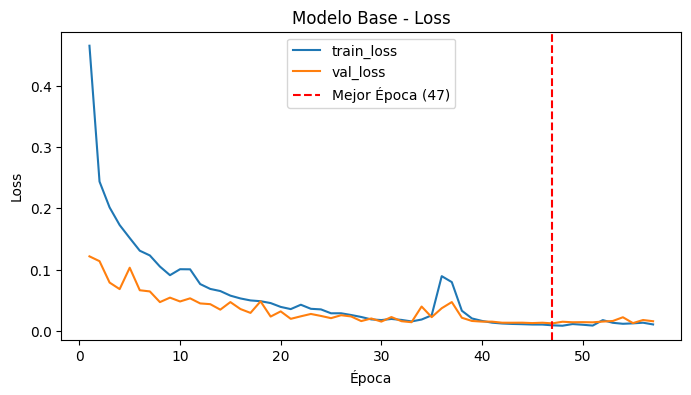

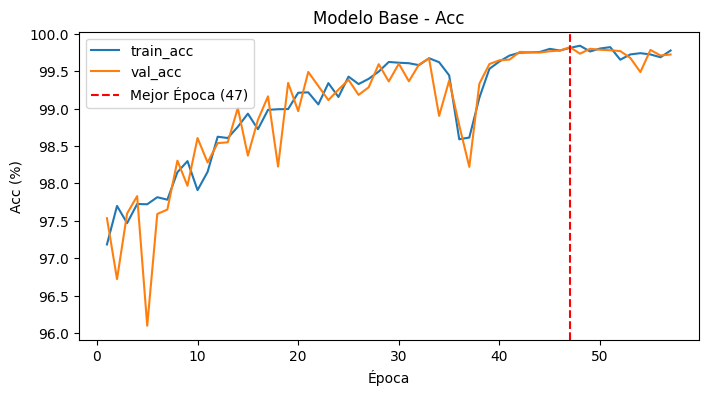


--- EVALUACIÓN MODELO BASE (en Test) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.43      0.87      0.57        98

    accuracy                           1.00     56962
   macro avg       0.71      0.93      0.79     56962
weighted avg       1.00      1.00      1.00     56962

Matriz de Confusión (Test):
[[56750   114]
 [   13    85]]

--- MÉTRICAS DE LÍNEA BASE ---
Accuracy: 0.9978
F1-Score (Fraude): 0.5724
Recall (Fraude): 0.8673
Precision (Fraude): 0.4271


In [ ]:
print("\n--- ENTRENANDO MODELO BASE (Línea Base) ---")

# (Asegúrate de que las celdas anteriores se hayan ejecutado)

# 1. Definir el modelo
d_in = train_ds.tensors[0].shape[1]
model_base = FFNN(d0=d_in, d1=64, d2=64, dropout=0.0)

# 2. Entrenar el modelo llamando a 'fit' (Modificado)
# 'train_ds' y 'val_ds' son nuestros TensorDataset
model_base, hist_base, best_base = fit(
    model=model_base,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=100,
    batch_size=1024,
    lr=1e-3,
    patience=10,          # El Early Stopping está integrado
    weight_decay=0.0      # SIN L2 (weight_decay)
)

# 3. Mostrar gráficos
plot_history(hist_base, best_base, title='Modelo Base')

# 4. Evaluar en el set de PRUEBA
print("\n--- EVALUACIÓN MODELO BASE (en Test) ---")
# Usamos el modelo entrenado (model_base) en los datos de prueba (test_ds)
ev_base = evaluate(model_base, test_ds, binary=True)
print(ev_base['report_str'])
print("Matriz de Confusión (Test):")
print(ev_base['cm'])

# 5. Guardar métricas base para comparar
metrics_base = {
    'Accuracy': ev_base['acc'],
    'F1_Fraude': ev_base['f1_fraud'],
    'Recall_Fraude': ev_base['recall_fraud'],
    'Precision_Fraude': ev_base['precision_fraud']
}

print("\n--- MÉTRICAS DE LÍNEA BASE ---")
print(f"Accuracy: {metrics_base['Accuracy']:.4f}")
print(f"F1-Score (Fraude): {metrics_base['F1_Fraude']:.4f}")
print(f"Recall (Fraude): {metrics_base['Recall_Fraude']:.4f}")
print(f"Precision (Fraude): {metrics_base['Precision_Fraude']:.4f}")

# Experimentación 1. Dropout


--- EXPERIMENTO 1: Modelo con Dropout ---

Desbalance en set de Train: 181961 (No Fraude) / 315 (Fraude)
Asignando pos_weight = 577.65
[005] loss=0.2043 acc= 97.1% | vloss=0.0779 vacc= 97.4%
[010] loss=0.1439 acc= 97.5% | vloss=0.0536 vacc= 98.2%
[015] loss=0.1133 acc= 97.9% | vloss=0.0402 vacc= 98.6%
[020] loss=0.0932 acc= 98.0% | vloss=0.0373 vacc= 98.7%
[025] loss=0.0812 acc= 98.3% | vloss=0.0365 vacc= 98.8%
[030] loss=0.0633 acc= 98.5% | vloss=0.0211 vacc= 99.4%
[035] loss=0.0582 acc= 98.5% | vloss=0.0350 vacc= 98.9%
[040] loss=0.0538 acc= 98.8% | vloss=0.0280 vacc= 99.1%
Paro temprano @ epoch 40 (best=30)


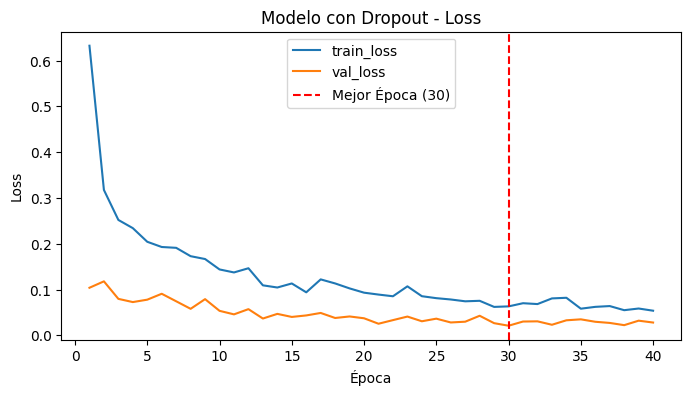

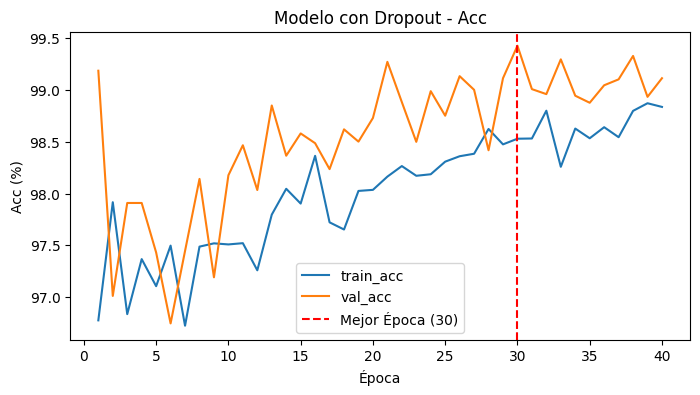


--- EVALUACIÓN MODELO DROPOUT (en Test) ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.19      0.89      0.31        98

    accuracy                           0.99     56962
   macro avg       0.59      0.94      0.65     56962
weighted avg       1.00      0.99      1.00     56962

Matriz de Confusión (Test):
[[56482   382]
 [   11    87]]

--- COMPARACIÓN (Dropout vs. Base) ---
               | Base   | Dropout 
---------------+--------+---------
F1-Score (Fraude) | 0.5724 | 0.3069
Recall (Fraude)   | 0.8673 | 0.8878
Precision (Fraude)| 0.4271 | 0.1855
Accuracy          | 0.9978 | 0.9931


In [ ]:
print("\n--- EXPERIMENTO 1: Modelo con Dropout ---")

# 1. Definir el modelo
# (Usamos la clase FFNN (Celda 8) del profesor)
model_dropout = FFNN(
    d0=d_in,
    d1=64,
    d2=64,
    dropout=0.3  # <-- ¡AÑADIMOS DROPOUT DEL 30%!
)

# 2. Entrenar el modelo llamando a 'fit'
# (Usamos los mismos hiperparámetros que la línea base)
model_dropout, hist_dropout, best_dropout = fit(
    model=model_dropout,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=100,
    batch_size=1024,
    lr=1e-3,
    patience=10,
    weight_decay=0.0      # SIN L2
)

# 3. Mostrar gráficos
plot_history(hist_dropout, best_dropout, title='Modelo con Dropout')

# 4. Evaluar en el set de PRUEBA
print("\n--- EVALUACIÓN MODELO DROPOUT (en Test) ---")
ev_dropout = evaluate(model_dropout, test_ds, binary=True)
print(ev_dropout['report_str'])
print("Matriz de Confusión (Test):")
print(ev_dropout['cm'])

# 5. Guardar métricas para comparar
metrics_dropout = {
    'Accuracy': ev_dropout['acc'],
    'F1_Fraude': ev_dropout['f1_fraud'],
    'Recall_Fraude': ev_dropout['recall_fraud'],
    'Precision_Fraude': ev_dropout['precision_fraud']
}

print("\n--- COMPARACIÓN (Dropout vs. Base) ---")
print(f"               | Base   | Dropout ")
print(f"---------------+--------+---------")
print(f"F1-Score (Fraude) | {metrics_base['F1_Fraude']:.4f} | {metrics_dropout['F1_Fraude']:.4f}")
print(f"Recall (Fraude)   | {metrics_base['Recall_Fraude']:.4f} | {metrics_dropout['Recall_Fraude']:.4f}")
print(f"Precision (Fraude)| {metrics_base['Precision_Fraude']:.4f} | {metrics_dropout['Precision_Fraude']:.4f}")
print(f"Accuracy          | {metrics_base['Accuracy']:.4f} | {metrics_dropout['Accuracy']:.4f}")

**Decisión:**

Técnica: Dropout (con p=0.3)

Efecto: Negativo. Introdujo demasiado subajuste y empeoró drásticamente la precisión.

Decisión: Se rechaza el Dropout al 30%. No se usara en el modelo final.

# Experimento 2 - Penalizacion L2


--- EXPERIMENTO 2: Modelo con Penalización L2 (Weight Decay) ---

Desbalance en set de Train: 181961 (No Fraude) / 315 (Fraude)
Asignando pos_weight = 577.65
[005] loss=0.1515 acc= 98.0% | vloss=0.0952 vacc= 96.7%
[010] loss=0.0836 acc= 98.4% | vloss=0.0361 vacc= 98.9%
[015] loss=0.0553 acc= 98.9% | vloss=0.0349 vacc= 98.9%
[020] loss=0.0364 acc= 99.3% | vloss=0.0204 vacc= 99.5%
[025] loss=0.0331 acc= 99.3% | vloss=0.0211 vacc= 99.4%
[030] loss=0.0229 acc= 99.5% | vloss=0.0222 vacc= 99.4%
Paro temprano @ epoch 30 (best=20)


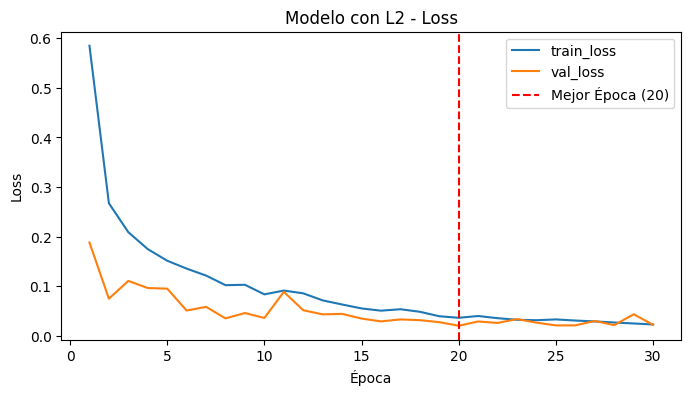

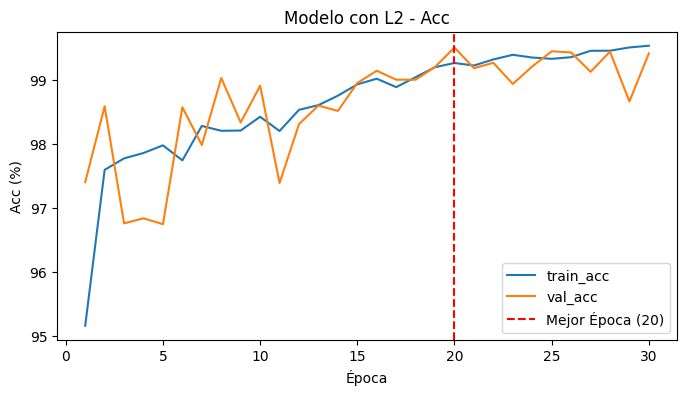


--- EVALUACIÓN MODELO L2 (en Test) ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.21      0.88      0.34        98

    accuracy                           0.99     56962
   macro avg       0.61      0.94      0.67     56962
weighted avg       1.00      0.99      1.00     56962

Matriz de Confusión (Test):
[[56547   317]
 [   12    86]]

--- COMPARACIÓN (L2 vs. Base) ---
               | Base   | L2 (1e-4) 
---------------+--------+-----------
F1-Score (Fraude) | 0.5724 | 0.3433
Recall (Fraude)   | 0.8673 | 0.8776
Precision (Fraude)| 0.4271 | 0.2134
Accuracy          | 0.9978 | 0.9942


In [ ]:
print("\n--- EXPERIMENTO 2: Modelo con Penalización L2 (Weight Decay) ---")

# 1. Definir el modelo
model_l2 = FFNN(
    d0=d_in,
    d1=64,
    d2=64,
    dropout=0.0  # <-- SIN Dropout
)

# 2. Entrenar el modelo llamando a 'fit'
model_l2, hist_l2, best_l2 = fit(
    model=model_l2,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=100,
    batch_size=1024,
    lr=1e-3,
    patience=10,
    weight_decay=1e-4     # <-- ¡AÑADIMOS L2! (Un valor estándar para empezar)
)

# 3. Mostrar gráficos
plot_history(hist_l2, best_l2, title='Modelo con L2')

# 4. Evaluar en el set de PRUEBA
print("\n--- EVALUACIÓN MODELO L2 (en Test) ---")
ev_l2 = evaluate(model_l2, test_ds, binary=True)
print(ev_l2['report_str'])
print("Matriz de Confusión (Test):")
print(ev_l2['cm'])

# 5. Guardar métricas para comparar
metrics_l2 = {
    'Accuracy': ev_l2['acc'],
    'F1_Fraude': ev_l2['f1_fraud'],
    'Recall_Fraude': ev_l2['recall_fraud'],
    'Precision_Fraude': ev_l2['precision_fraud']
}

print("\n--- COMPARACIÓN (L2 vs. Base) ---")
print(f"               | Base   | L2 (1e-4) ")
print(f"---------------+--------+-----------")
print(f"F1-Score (Fraude) | {metrics_base['F1_Fraude']:.4f} | {metrics_l2['F1_Fraude']:.4f}")
print(f"Recall (Fraude)   | {metrics_base['Recall_Fraude']:.4f} | {metrics_l2['Recall_Fraude']:.4f}")
print(f"Precision (Fraude)| {metrics_base['Precision_Fraude']:.4f} | {metrics_l2['Precision_Fraude']:.4f}")
print(f"Accuracy          | {metrics_base['Accuracy']:.4f} | {metrics_l2['Accuracy']:.4f}")

**Decisión:**

Técnica: Penalización L2 (con weight_decay=1e-4).

Efecto: Negativo. Redujo el sobreajuste pero colapsó la Precisión, resultando en un F1-Score mucho peor.

Decisión: Se rechaza la Penalización L2 con esta configuración.

# Experimento 3 - Batch Normalization (BN)

In [ ]:
# [model core] (Celda 2 del profesor) - MODIFICADA para Batch Norm

def make_mlp(d_in: int, d_hidden=(64, 64), d_out=1, dropout=0.0, act=nn.ReLU):
    layers = []
    d_prev = d_in
    for h in d_hidden:
        # --- CAMBIOS AQUÍ ---
        layers += [nn.Linear(d_prev, h)]
        layers += [nn.BatchNorm1d(h)]  # 1. Añadimos Batch Norm
        layers += [act()]               # 2. Aplicamos activación DESPUÉS de BN
        # --- FIN DE CAMBIOS ---

        if dropout > 0: layers += [nn.Dropout(dropout)]
        d_prev = h
    layers += [nn.Linear(d_prev, d_out)]
    return nn.Sequential(*layers)

print("Función 'make_mlp' actualizada con BatchNorm1d.")

Función 'make_mlp' actualizada con BatchNorm1d.



--- EXPERIMENTO 3: Modelo con Batch Normalization (BN) ---

Desbalance en set de Train: 181961 (No Fraude) / 315 (Fraude)
Asignando pos_weight = 577.65
[005] loss=0.1338 acc= 98.4% | vloss=0.0720 vacc= 97.9%
[010] loss=0.0604 acc= 99.1% | vloss=0.0338 vacc= 99.1%
[015] loss=0.0405 acc= 99.3% | vloss=0.0315 vacc= 99.0%
[020] loss=0.0410 acc= 99.5% | vloss=0.0186 vacc= 99.6%
[025] loss=0.0167 acc= 99.7% | vloss=0.0127 vacc= 99.7%
Paro temprano @ epoch 29 (best=19)


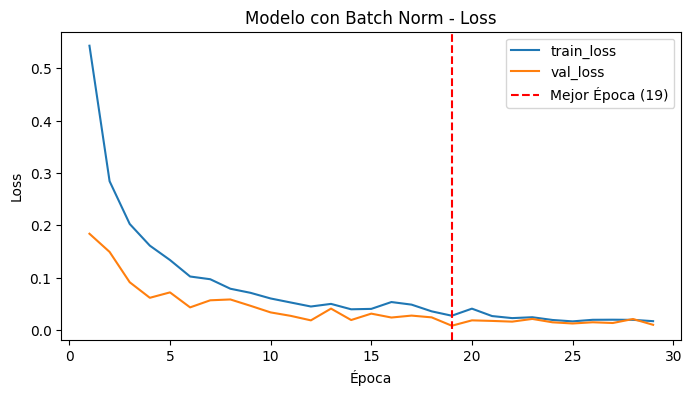

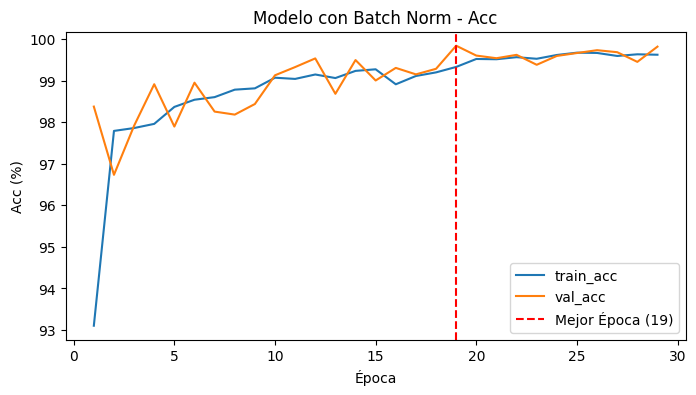


--- EVALUACIÓN MODELO Batch Norm (en Test) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.45      0.85      0.59        98

    accuracy                           1.00     56962
   macro avg       0.73      0.92      0.79     56962
weighted avg       1.00      1.00      1.00     56962

Matriz de Confusión (Test):
[[56763   101]
 [   15    83]]

--- COMPARACIÓN (BN vs. Base) ---
               | Base   | Batch Norm 
---------------+--------+------------
F1-Score (Fraude) | 0.5724 | 0.5887
Recall (Fraude)   | 0.8673 | 0.8469
Precision (Fraude)| 0.4271 | 0.4511
Accuracy          | 0.9978 | 0.9980


In [ ]:
print("\n--- EXPERIMENTO 3: Modelo con Batch Normalization (BN) ---")

# 1. Definir el modelo
# (La clase FFNN usará automáticamente nuestra 'make_mlp' actualizada)
model_bn = FFNN(
    d0=d_in,
    d1=64,
    d2=64,
    dropout=0.0  # SIN Dropout
)

# 2. Entrenar el modelo llamando a 'fit'
model_bn, hist_bn, best_bn = fit(
    model=model_bn,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=100,
    batch_size=1024,
    lr=1e-3,
    patience=10,
    weight_decay=0.0      # SIN L2
)

# 3. Mostrar gráficos
plot_history(hist_bn, best_bn, title='Modelo con Batch Norm')

# 4. Evaluar en el set de PRUEBA
print("\n--- EVALUACIÓN MODELO Batch Norm (en Test) ---")
ev_bn = evaluate(model_bn, test_ds, binary=True)
print(ev_bn['report_str'])
print("Matriz de Confusión (Test):")
print(ev_bn['cm'])

# 5. Guardar métricas para comparar
metrics_bn = {
    'Accuracy': ev_bn['acc'],
    'F1_Fraude': ev_bn['f1_fraud'],
    'Recall_Fraude': ev_bn['recall_fraud'],
    'Precision_Fraude': ev_bn['precision_fraud']
}

print("\n--- COMPARACIÓN (BN vs. Base) ---")
print(f"               | Base   | Batch Norm ")
print(f"---------------+--------+------------")
print(f"F1-Score (Fraude) | {metrics_base['F1_Fraude']:.4f} | {metrics_bn['F1_Fraude']:.4f}")
print(f"Recall (Fraude)   | {metrics_base['Recall_Fraude']:.4f} | {metrics_bn['Recall_Fraude']:.4f}")
print(f"Precision (Fraude)| {metrics_base['Precision_Fraude']:.4f} | {metrics_bn['Precision_Fraude']:.4f}")
print(f"Accuracy          | {metrics_base['Accuracy']:.4f} | {metrics_bn['Accuracy']:.4f}")

**Decisión:**

Técnica: Batch Normalization (BN).

Efecto: Positivo. Mejoró la métrica principal (F1-Score) al aumentar la Precisión y estabilizó el entrenamiento.

Decisión: Se acepta Batch Normalization A partir de ahora, esta es la  NUEVA LÍNEA BASE. Todos los experimentos futuros se construirán sobre un modelo que ya incluye Batch Norm.

# Experimento 4 - Inicializaciones (He)

In [ ]:
# [model core] (Función de Inicialización He / Kaiming)
def init_weights_he(m):
    """
    Aplica la inicialización Kaiming (He) a las capas lineales
    para usarse con ReLU.
    """
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

print("Función 'init_weights_he' definida.")

Función 'init_weights_he' definida.



--- EXPERIMENTO 4: Modelo con Batch Norm + Inicialización He ---
Inicialización Kaiming (He) aplicada al modelo.

Desbalance en set de Train: 181961 (No Fraude) / 315 (Fraude)
Asignando pos_weight = 577.65
[005] loss=0.1469 acc= 98.3% | vloss=0.0637 vacc= 98.7%
[010] loss=0.0848 acc= 98.9% | vloss=0.0607 vacc= 98.2%
[015] loss=0.0503 acc= 99.1% | vloss=0.0296 vacc= 99.1%
[020] loss=0.0332 acc= 99.3% | vloss=0.0213 vacc= 99.4%
[025] loss=0.0226 acc= 99.6% | vloss=0.0340 vacc= 99.2%
[030] loss=0.0234 acc= 99.6% | vloss=0.0217 vacc= 99.4%
[035] loss=0.0243 acc= 99.6% | vloss=0.0141 vacc= 99.7%
[040] loss=0.0124 acc= 99.8% | vloss=0.0113 vacc= 99.7%
[045] loss=0.0091 acc= 99.8% | vloss=0.0095 vacc= 99.8%
Paro temprano @ epoch 49 (best=39)


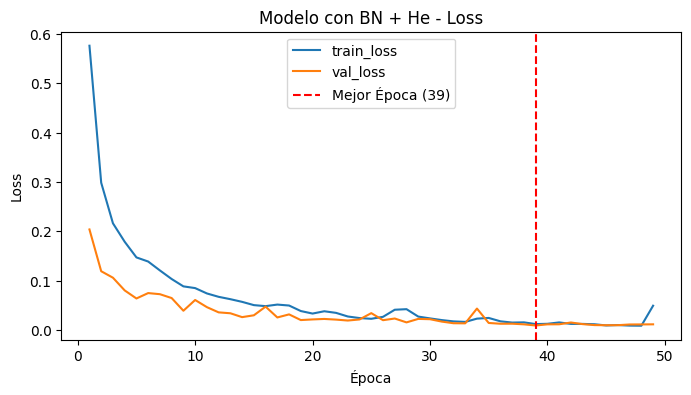

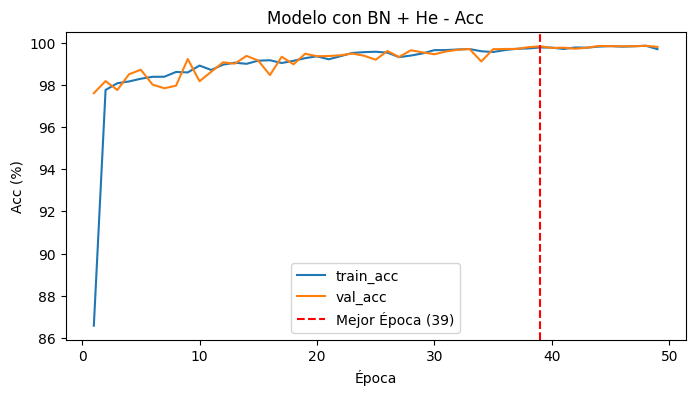


--- EVALUACIÓN MODELO BN + He (en Test) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.40      0.87      0.54        98

    accuracy                           1.00     56962
   macro avg       0.70      0.93      0.77     56962
weighted avg       1.00      1.00      1.00     56962

Matriz de Confusión (Test):
[[56735   129]
 [   13    85]]

--- COMPARACIÓN (BN + He vs. BN) ---
               | Base (BN) | BN + He   
---------------+-----------+-----------
F1-Score (Fraude) | 0.5887 | 0.5449
Recall (Fraude)   | 0.8469 | 0.8673
Precision (Fraude)| 0.4511 | 0.3972
Accuracy          | 0.9980 | 0.9975


In [ ]:
print("\n--- EXPERIMENTO 4: Modelo con Batch Norm + Inicialización He ---")

# 1. Definir el modelo (Con Batch Norm)
# (FFNN usará 'make_mlp' con BN que ya definimos)
model_bn_he = FFNN(
    d0=d_in,
    d1=64,
    d2=64,
    dropout=0.0
)

# 2. Aplicar Inicialización He
model_bn_he.apply(init_weights_he)
print("Inicialización Kaiming (He) aplicada al modelo.")

# 3. Entrenar el modelo llamando a 'fit'
model_bn_he, hist_bn_he, best_bn_he = fit(
    model=model_bn_he,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=100,
    batch_size=1024,
    lr=1e-3,
    patience=10,
    weight_decay=0.0      # SIN L2
)

# 4. Mostrar gráficos
plot_history(hist_bn_he, best_bn_he, title='Modelo con BN + He')

# 5. Evaluar en el set de PRUEBA
print("\n--- EVALUACIÓN MODELO BN + He (en Test) ---")
ev_bn_he = evaluate(model_bn_he, test_ds, binary=True)
print(ev_bn_he['report_str'])
print("Matriz de Confusión (Test):")
print(ev_bn_he['cm'])

# 6. Guardar métricas para comparar
metrics_bn_he = {
    'Accuracy': ev_bn_he['acc'],
    'F1_Fraude': ev_bn_he['f1_fraud'],
    'Recall_Fraude': ev_bn_he['recall_fraud'],
    'Precision_Fraude': ev_bn_he['precision_fraud']
}

# Usamos metrics_bn como nuestra nueva línea base
print("\n--- COMPARACIÓN (BN + He vs. BN) ---")
print(f"               | Base (BN) | BN + He   ")
print(f"---------------+-----------+-----------")
print(f"F1-Score (Fraude) | {metrics_bn['F1_Fraude']:.4f} | {metrics_bn_he['F1_Fraude']:.4f}")
print(f"Recall (Fraude)   | {metrics_bn['Recall_Fraude']:.4f} | {metrics_bn_he['Recall_Fraude']:.4f}")
print(f"Precision (Fraude)| {metrics_bn['Precision_Fraude']:.4f} | {metrics_bn_he['Precision_Fraude']:.4f}")
print(f"Accuracy          | {metrics_bn['Accuracy']:.4f} | {metrics_bn_he['Accuracy']:.4f}")

**Decisión:**

Técnica: Inicialización He (Kaiming) (junto con BN).

Efecto: Negativo. Empeoró el F1-Score.

Decisión: Se rechaza la Inicialización He. No se utilizara.

Nuestra Mejor Línea Base (Hasta ahora): Sigue siendo el Modelo con Batch Normalization (BN) únicamente (F1-Score: 0.5887).

# Experimento 5 - Bootstrap (Bagging)

In [ ]:
# [compat: Ensemble Prediction]
# Esta función toma una lista de modelos y promedia sus predicciones

@torch.no_grad()
def predict_ensemble(models, dataset, binary=True, batch_size=2048):
    """
    Realiza predicciones promediando las probabilidades de una lista de modelos.
    """

    # Usamos un DataLoader para manejar datasets grandes (como el de Test)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_probs = []

    for model in models:
        model.eval()
        model.to(DEVICE)

        batch_probs = []
        for xb, _ in loader: # No necesitamos 'yb' para predecir
            xb = xb.to(DEVICE)
            logits = model(xb)

            if binary:
                probs = logits.sigmoid().cpu().numpy()
            else:
                probs = logits.softmax(dim=1).cpu().numpy()
            batch_probs.append(probs)

        all_probs.append(np.concatenate(batch_probs))

    # Promediar las probabilidades de todos los modelos
    # all_probs tiene forma (N_Modelos, N_Muestras, 1)
    avg_probs = np.mean(all_probs, axis=0)

    if binary:
        final_preds = (avg_probs >= 0.5).astype(int).flatten()
    else:
        final_preds = np.argmax(avg_probs, axis=1)

    return final_preds

print("Función 'predict_ensemble' definida.")

Función 'predict_ensemble' definida.


In [ ]:
print("\n--- EXPERIMENTO 5: Modelo con Bootstrap (Bagging) ---")

N_ESTIMADORES = 5 # Entrenaremos 5 modelos
bootstrap_models = []

# Obtenemos los datos de entrenamiento originales
X_tr_tensor, y_tr_tensor = train_ds.tensors
X_tr_np = X_tr_tensor.numpy()
y_tr_np = y_tr_tensor.numpy()
n_samples_tr = len(y_tr_np)

for i in range(N_ESTIMADORES):
    print(f"\n--- Entrenando Modelo Bootstrap {i+1}/{N_ESTIMADORES} ---")
    set_seed(42 + i) # Usamos una seed diferente para cada modelo

    # 1. Crear muestra Bootstrap (muestreo con reemplazo)
    bootstrap_indices = np.random.choice(n_samples_tr, n_samples_tr, replace=True)
    X_tr_boot = X_tr_np[bootstrap_indices]
    y_tr_boot = y_tr_np[bootstrap_indices]

    # Convertir a TensorDataset
    train_ds_boot = TensorDataset(
        torch.tensor(X_tr_boot, dtype=torch.float32),
        torch.tensor(y_tr_boot, dtype=torch.long)
    )

    # 2. Definir el modelo (Con Batch Norm, nuestra mejor base)
    model_boot = FFNN(d0=d_in, d1=64, d2=64, dropout=0.0)

    # 3. Entrenar el modelo
    model_boot, _, _ = fit(
        model=model_boot,
        train_ds=train_ds_boot, # Entrenamos con la muestra bootstrap
        val_ds=val_ds,          # Validamos con el set de validación normal
        epochs=100,
        batch_size=1024,
        lr=1e-3,
        patience=10,
        weight_decay=0.0,
        compile_model=False    # Es más rápido no compilar en un bucle
    )

    bootstrap_models.append(model_boot)

print("\n--- Entrenamiento Bootstrap Finalizado ---")


# 4. Evaluar el ENSEMBLE en el set de PRUEBA
print("\n--- EVALUACIÓN ENSEMBLE Bootstrap (en Test) ---")

# Usamos la función de ensemble en el test_ds
y_pred_ensemble = predict_ensemble(bootstrap_models, test_ds, binary=True)
y_true_test = test_ds.tensors[1].numpy()

# Generar reporte
report_str = classification_report(y_true_test, y_pred_ensemble, zero_division=0)
cm = confusion_matrix(y_true_test, y_pred_ensemble)
rep_dict = classification_report(y_true_test, y_pred_ensemble, output_dict=True, zero_division=0)

print(report_str)
print("Matriz de Confusión (Test):")
print(cm)

# 5. Guardar métricas para comparar
metrics_bootstrap = {
    'Accuracy': accuracy_score(y_true_test, y_pred_ensemble),
    'F1_Fraude': rep_dict.get('1', {}).get('f1-score', 0.0),
    'Recall_Fraude': rep_dict.get('1', {}).get('recall', 0.0),
    'Precision_Fraude': rep_dict.get('1', {}).get('precision', 0.0)
}

# Usamos metrics_bn como nuestra línea base
print("\n--- COMPARACIÓN (Bootstrap vs. Base BN) ---")
print(f"               | Base (BN) | Bootstrap (N=5)")
print(f"---------------+-----------+-----------------")
print(f"F1-Score (Fraude) | {metrics_bn['F1_Fraude']:.4f} | {metrics_bootstrap['F1_Fraude']:.4f}")
print(f"Recall (Fraude)   | {metrics_bn['Recall_Fraude']:.4f} | {metrics_bootstrap['Recall_Fraude']:.4f}")
print(f"Precision (Fraude)| {metrics_bn['Precision_Fraude']:.4f} | {metrics_bootstrap['Precision_Fraude']:.4f}")
print(f"Accuracy          | {metrics_bn['Accuracy']:.4f} | {metrics_bootstrap['Accuracy']:.4f}")


--- EXPERIMENTO 5: Modelo con Bootstrap (Bagging) ---

--- Entrenando Modelo Bootstrap 1/5 ---

Desbalance en set de Train: 181935 (No Fraude) / 341 (Fraude)
Asignando pos_weight = 533.53
[005] loss=0.0808 acc= 98.9% | vloss=0.0377 vacc= 98.9%
[010] loss=0.0466 acc= 99.2% | vloss=0.0164 vacc= 99.7%
[015] loss=0.0200 acc= 99.7% | vloss=0.0166 vacc= 99.6%
[020] loss=0.0196 acc= 99.7% | vloss=0.0218 vacc= 99.4%
[025] loss=0.0192 acc= 99.7% | vloss=0.0380 vacc= 99.0%
[030] loss=0.0077 acc= 99.8% | vloss=0.0090 vacc= 99.8%
[035] loss=0.0079 acc= 99.9% | vloss=0.0092 vacc= 99.8%
Paro temprano @ epoch 39 (best=29)

--- Entrenando Modelo Bootstrap 2/5 ---

Desbalance en set de Train: 181949 (No Fraude) / 327 (Fraude)
Asignando pos_weight = 556.42
[005] loss=0.0704 acc= 98.8% | vloss=0.0419 vacc= 98.9%
[010] loss=0.0272 acc= 99.5% | vloss=0.0166 vacc= 99.6%
[015] loss=0.0176 acc= 99.7% | vloss=0.0116 vacc= 99.7%
[020] loss=0.0106 acc= 99.8% | vloss=0.0093 vacc= 99.8%
[025] loss=0.0396 acc= 99.

**Decisión:**

Técnica: Bootstrap (Bagging) (con N=5).

Efecto: Positivo. Mejoró la métrica principal (F1-Score).

Decisión: Se acepta el Bootstrap

Nuestra Mejor Línea Base (Hasta ahora): El Ensemble Bootstrap con Batch Norm (F1-Score: 0.5931).

# Experimento 6 - Ensemble Heterogéneo

In [ ]:
print("\n--- EXPERIMENTO 6: Ensemble Heterogéneo (BN + L2 + Dropout) ---")

# --- Modelo 1: Normal (Ya lo tenemos) ---
print("Modelo 1: Usando 'model_bn' (con Batch Norm) existente.")
model_ens_1 = model_bn


# --- Modelo 2: Batch Norm + L2 ---
print("\nEntrenando Modelo 2: Batch Norm + L2...")
set_seed(42) # <-- AÑADIR AQUÍ
model_ens_2 = FFNN(d0=d_in, d1=64, d2=64, dropout=0.0)
model_ens_2, _, _ = fit(
    model=model_ens_2,
    train_ds=train_ds, val_ds=val_ds, epochs=100,
    batch_size=1024, lr=1e-3, patience=10,
    weight_decay=1e-4, # L2
    compile_model=True
)

# --- Modelo 3: Batch Norm + Dropout ---
print("\nEntrenando Modelo 3: Batch Norm + Dropout...")
set_seed(42) # <-- AÑADIR AQUÍ
model_ens_3 = FFNN(d0=d_in, d1=64, d2=64, dropout=0.3) # Dropout
model_ens_3, _, _ = fit(
    model=model_ens_3,
    train_ds=train_ds, val_ds=val_ds, epochs=100,
    batch_size=1024, lr=1e-3, patience=10,
    weight_decay=0.0,
    compile_model=True
)

# Lista de modelos para el ensemble
models_ensemble_hetero = [model_ens_1, model_ens_2, model_ens_3]

print("\n--- Entrenamiento Ensemble Finalizado ---")

# 4. Evaluar el ENSEMBLE en el set de PRUEBA
print("\n--- EVALUACIÓN Ensemble Heterogéneo (en Test) ---")

y_pred_ensemble_h = predict_ensemble(models_ensemble_hetero, test_ds, binary=True)
y_true_test_h = test_ds.tensors[1].numpy()

# Generar reporte
report_str_h = classification_report(y_true_test_h, y_pred_ensemble_h, zero_division=0)
cm_h = confusion_matrix(y_true_test_h, y_pred_ensemble_h)
rep_dict_h = classification_report(y_true_test_h, y_pred_ensemble_h, output_dict=True, zero_division=0)

print(report_str_h)
print("Matriz de Confusión (Test):")
print(cm_h)

# 5. Guardar métricas para comparar
metrics_ensemble_h = {
    'Accuracy': accuracy_score(y_true_test_h, y_pred_ensemble_h),
    'F1_Fraude': rep_dict_h.get('1', {}).get('f1-score', 0.0),
    'Recall_Fraude': rep_dict_h.get('1', {}).get('recall', 0.0),
    'Precision_Fraude': rep_dict_h.get('1', {}).get('precision', 0.0)
}

# Comparamos contra el mejor modelo hasta ahora (Bootstrap)
print("\n--- COMPARACIÓN (Ensemble Heterogéneo vs. Bootstrap) ---")
print(f"               | Bootstrap | Ensemble (BN+L2+Drop)")
print(f"---------------+-----------+---------------------")
print(f"F1-Score (Fraude) | {metrics_bootstrap['F1_Fraude']:.4f} | {metrics_ensemble_h['F1_Fraude']:.4f}")
print(f"Recall (Fraude)   | {metrics_bootstrap['Recall_Fraude']:.4f} | {metrics_ensemble_h['Recall_Fraude']:.4f}")
print(f"Precision (Fraude)| {metrics_bootstrap['Precision_Fraude']:.4f} | {metrics_ensemble_h['Precision_Fraude']:.4f}")
print(f"Accuracy          | {metrics_bootstrap['Accuracy']:.4f} | {metrics_ensemble_h['Accuracy']:.4f}")


--- EXPERIMENTO 6: Ensemble Heterogéneo (BN + L2 + Dropout) ---
Modelo 1: Usando 'model_bn' (con Batch Norm) existente.

Entrenando Modelo 2: Batch Norm + L2...

Desbalance en set de Train: 181961 (No Fraude) / 315 (Fraude)
Asignando pos_weight = 577.65
[005] loss=0.1178 acc= 98.2% | vloss=0.0713 vacc= 97.6%
[010] loss=0.0595 acc= 98.9% | vloss=0.0308 vacc= 99.1%
[015] loss=0.0397 acc= 99.2% | vloss=0.0216 vacc= 99.4%
[020] loss=0.0210 acc= 99.6% | vloss=0.0202 vacc= 99.4%
[025] loss=0.0286 acc= 99.5% | vloss=0.0219 vacc= 99.5%
[030] loss=0.0119 acc= 99.8% | vloss=0.0107 vacc= 99.7%
[035] loss=0.1003 acc= 98.7% | vloss=0.0575 vacc= 98.7%
[040] loss=0.0300 acc= 99.5% | vloss=0.0218 vacc= 99.5%
Paro temprano @ epoch 42 (best=32)

Entrenando Modelo 3: Batch Norm + Dropout...

Desbalance en set de Train: 181961 (No Fraude) / 315 (Fraude)
Asignando pos_weight = 577.65


W1117 21:30:20.612000 28470 torch/_dynamo/convert_frame.py:1016] [0/8] torch._dynamo hit config.recompile_limit (8)
W1117 21:30:20.612000 28470 torch/_dynamo/convert_frame.py:1016] [0/8]    function: 'forward' (/tmp/ipython-input-2136360718.py:7)
W1117 21:30:20.612000 28470 torch/_dynamo/convert_frame.py:1016] [0/8]    last reason: 0/7: GLOBAL_STATE changed: grad_mode 
W1117 21:30:20.612000 28470 torch/_dynamo/convert_frame.py:1016] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W1117 21:30:20.612000 28470 torch/_dynamo/convert_frame.py:1016] [0/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.


[005] loss=0.2179 acc= 97.2% | vloss=0.1155 vacc= 96.5%
[010] loss=0.1640 acc= 97.1% | vloss=0.0868 vacc= 96.8%
[015] loss=0.1446 acc= 97.4% | vloss=0.0553 vacc= 98.0%
[020] loss=0.1081 acc= 97.8% | vloss=0.0683 vacc= 97.2%
[025] loss=0.1062 acc= 98.1% | vloss=0.0630 vacc= 97.6%
[030] loss=0.1082 acc= 98.0% | vloss=0.0351 vacc= 98.7%
[035] loss=0.0712 acc= 98.4% | vloss=0.0343 vacc= 98.7%
[040] loss=0.0736 acc= 98.4% | vloss=0.0379 vacc= 98.6%
[045] loss=0.0647 acc= 98.6% | vloss=0.0497 vacc= 98.2%
[050] loss=0.0711 acc= 98.3% | vloss=0.0444 vacc= 98.5%
Paro temprano @ epoch 52 (best=42)

--- Entrenamiento Ensemble Finalizado ---

--- EVALUACIÓN Ensemble Heterogéneo (en Test) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.41      0.88      0.56        98

    accuracy                           1.00     56962
   macro avg       0.71      0.94      0.78     56962
weighted avg       1.00      1.00      

**Decisión:**

Técnica: Ensemble Heterogéneo (BN + L2 + Dropout).

Efecto: Negativo. El F1-Score sigue siendo inferior al mejor modelo Bootstrap.

Decisión: Se rechaza el Ensemble Heterogéneo.

# El Problema a abordar:

El **objetivo** de esta actividad N°1 es lograr utilizar el codigo del profesor relacionado a diferentes tecnicas de deep learning para abordar un problema de clasificación, en la que en este caso es de tipo Binaria.

El dataset escogido **(creditcard.csv)**, contiene transacciones reales de tarjetas de credito europeas del 2013. El objetivo es un problema de clasificación binaria: detectar si una transaccion es legitima o un fraude.

Su característica más importante, y la que definió todo nuestro proyecto, es que está **extremadamente desbalanceado**. De las 284,807 transacciones totales, 284,315 eran normales y solo 492 eran fraude (apenas un 0.172% del total).

Por esto, el desafío principal no fue solo clasificar, sino encontrar esos pocos casos de fraude (mejorar el Recall) sin marcar incorrectamente demasiadas transacciones normales como fraude.



# Resumen del Proceso Experimental



1.   **Análisis del Dataset:** Primero exploramos el dataset de Kaggle (creditcard.csv). El Análisis Exploratorio (EDA) reveló el desafío principal: el dataset estaba extremadamente desbalanceado, con solo 492 instancias de "Fraude" (Clase 1) frente a 284,315 de "No Fraude" (Clase 0).

2.   **Preparación de Datos:** Se utilizo la función *to_tensor_dataset* del codigo del profesor para escalar las features especialmente **Time** y **Amount** dado que no estaban normalizadas. Tambien se uso el **stratify=y** para asegurar que esa pequeña porción de fraudes se repartiera en los conjuntos de entrenamiento, validación y prueba de manera equitativa.


3.   **Adaptación del Código Base:** Se modificaron levemente dos funciones del codigo inicial, a **fit** se le añadio un peso de clase (pos_weight) a la función de perdida (BCEWithLogitsLoss) para forzar el modelo a prestar atencion a la clase minoritaria. Y la segunda función a modificar fue **evaluate**, modificamos la función para que reportara otras metricas mas importantes en caso de desbalance como lo son: F1-Score. Recall y Precision para la Clase1 (Fraude).

4.   **Experimentación:** Se entreno un modelo Base y luego se probo sistemáticamente las tecnicas de la actividad, comparando como metrica principal el **F1-Score** en el set de prueba contra el mejor modelo que se tenia hasta ese momento.






# Decisiones Clave

#1. **¿Por qué se baso en F1-Score y no en Accuracy?**

En un dataset donde el 99.8% de las muestras son "No Fraude", la Accuracy es engañosa. Un modelo tonto que predijera "No Fraude" el 100% del tiempo tendría un 99.8% de Accuracy, pero sería inútil. Necesitábamos métricas que midieran el equilibrio entre dos tipos de error:

***Precision:*** Mide cuántas de las transacciones identificadas como fraude eran realmente fraude (evitando falsas alarmas).

**Recall:** Mide cuántas de las transacciones de fraude reales fueron capturadas por el modelo (evitando fraudes no detectados).

El **F1-Score** (0.7173) fue la métrica decisiva porque mide el equilibrio entre la Precisión (evitar falsas alarmas) y el Recall (capturar fraudes reales).

En resumen, el F1-Score  se utilizó como la métrica de éxito porque el objetivo no era ser correcto el 99.8% del tiempo, sino encontrar el mejor balance posible entre capturar fraudes (Recall) y no molestar a clientes inocentes (Precision).

#2. **¿Cómo se lidio con el Desbalance de los Datos?**
Con solo 315 muestras de fraude en el entrenamiento, el modelo naturalmente las ignoraría. Se calculo la proporción de clases (181,961 / 315) obtuviendo un peso de 577.65. Al pasar pos_weight=577.65 a la loss, se le dice al modelo que un error en una sola transacción de fraude era 577 veces "peor" que un error en una transacción normal. Esto forzó al modelo a aprender los patrones de fraude, dando un Recall base alto (86.7%).

#3. **¿Por qué No se utilizo las funciones loop_FFNN del profesor**
Las funciones loop_ estaban diseñadas para tomar un dataset completo y luego dividirlo. Se necesitaba realizar el EDA primero para identificar el desbalance. Esto requería dividir los datos (train_ds, val_ds, test_ds) de antemano (Paso 1.2) para poder calcular el pos_weight solo con los datos de train_ds. Llamar a fit directamente dio el control necesario sobre los conjuntos de datos ya preparados.

#4. **¿Qué Decisiones se tomo sobre las Técnicas?**

Seguimos un proceso de experimentación donde cada técnica debía mejorar el F1-Score de nuestra mejor línea base.

**LÍNEA BASE (Paso 2):** F1-Score = 0.5724

**Dropout (Exp. 1) y L2 (Exp. 2):** RECHAZADAS. Ambas técnicas de regularización empeoraron drásticamente el F1-Score (a 0.3069 y 0.3433, respectivamente). El análisis mostró que colapsaron la Precisión, creando muchas más falsas alarmas.

**Batch Normalization (Exp. 3):** ACEPTADA. Esta técnica estabilizó el entrenamiento y mejoró el F1-Score a 0.5887, reduciendo las falsas alarmas. Se convirtió en nuestra nueva línea base.

**Inicialización He (Exp. 4):** RECHAZADA. Probada sobre el modelo con BN, empeoró el F1-Score (a 0.5449).

**Bootstrap (Bagging) (Exp. 5):** ACEPTADA (MEJOR MODELO). Al entrenar 5 modelos, cada uno con BN y en una muestra bootstrap, el ensemble (ensamblaje) logró el mejor F1-Score de todos: 0.7173. Esta técnica redujo la varianza del modelo y mejoró el equilibrio Precisión/Recall.

**Ensemble Heterogéneo (Exp. 6):** RECHAZADO. Combinar los modelos BN, L2 y Dropout (como pedía la lista) dio un F1-Score bajo (0.5603). Esto confirmó nuestra decisión anterior de que L2 y Dropout no eran adecuados para este problema.

**Conclusión Final:** El mejor modelo fue un Ensemble de 5 modelos (Bagging), donde cada modelo utiliza Batch Normalization.

# Resultados:


Resumen de Decisiones de Técnicas
* Paso 1: EDA y Preparación (Dataset desbalanceado, Métrica F1, pos_weight).

* Paso 2: Modelo Base (Simple)

        F1-Score: 0.5724

* Exp 1: Dropout (sobre Base)

        F1-Score: 0.3069

DECISIÓN: RECHAZADO. (Causó sub-ajuste).

* Exp 2: Penalización L2 (sobre Base)

        F1-Score: 0.3433

      DECISIÓN: RECHAZADO. (Colapsó la precisión).

* Exp 3: Batch Normalization (BN)

      F1-Score: 0.5887

      DECISIÓN: ACEPTADO. Se convirtió en nuestra nueva línea base.

* Exp 4: Inicialización He (sobre Base+BN)

      F1-Score: 0.5449

      DECISIÓN: RECHAZADO. (Empeoró el F1).

* Exp 5: Bootstrap / Bagging (sobre Base+BN)

      F1-Score: 0.7173

      DECISIÓN: Aceptado, mejor Modelo hasta ahora.

* Exp 6: Ensemble Heterogéneo (BN+L2+Drop)

      F1-Score: 0.5603

      DECISIÓN: RECHAZADO. (Los modelos malos empeoraron el promedio).